<a href="https://colab.research.google.com/github/VIVIMLC/Bank-Marketing-Prediction/blob/main/Copy_of_github_portfolio_predictive_analytics_storytellingVleyva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GitHub Portfolio: Predictive Analytics Storytelling

ISOM 835 — Predictive Analytics | Sawyer Business School

You've Been Hired
A company just brought you on as a data analyst. They have a business problem and a dataset. They need two things from you:

A working predictive model — Can you actually predict the outcome?
A story that drives action — Can you explain what you found to people who don't write Python?

Your deliverable is a professional GitHub repository containing your analysis notebook and a README that tells the story. Think of the README as the executive summary that the VP reads over coffee — and the notebook as the appendix they'll never open unless they're impressed.

Choose Your Client

Pick one of the three business scenarios below. Each involves a real-world dataset and a classification problem. Choose the industry that interests you most — your portfolio will be more compelling when you care about the problem.

Client A	Client B	Client C

Industry	Hospitality	Financial Services	E-Commerce

Client	A hotel chain in Portugal	A retail bank in Europe	An online retail company

Problem	37% of bookings get cancelled — can we predict which ones?	Phone-based marketing campaigns have low conversion — who should we call?	Only 15% of website visitors buy — can we identify who will convert?
Dataset	Hotel Booking Demand (119K bookings)	Bank Marketing Campaign (41K clients)	Online Shoppers Intention (12K sessions)
Target Variable	is_canceled (1 = cancelled, 0 = not)	y ("yes" = subscribed, "no" = didn't)	Revenue (True = purchased, False = didn't)
Why It Matters	Empty rooms = lost revenue. Overbooking = angry guests.	Every unnecessary call costs money. Every missed lead costs more.	Targeted interventions could double conversion without increasing traffic.


Step 0: Load Your Dataset

Run the starter code for the client you chose. Each cell loads the data into a DataFrame called df so the rest of your workflow is the same regardless of which dataset you pick.

Only run the cell for your chosen client.

In [ ]:
# ============================================================
# CLIENT B: Bank Marketing Campaign
# ============================================================
# A European retail bank wants to predict which clients will subscribe
# to a term deposit after a phone marketing campaign.
# Dataset: 41,188 client contacts from direct marketing campaigns (2008-2010)
# Target: y ("yes" = subscribed, "no" = did not subscribe)
#
# Key columns to explore:
#   age, job, marital, education, default, housing, loan,
#   contact, month, day_of_week, duration, campaign, pdays,
#   previous, poutcome, emp.var.rate, cons.price.idx, cons.conf.idx,
#   euribor3m, nr.employed
# ============================================================

!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=222)  # Bank Marketing
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f"Dataset loaded: {df.shape[0]:,} clients, {df.shape[1]} columns")
df.head()

Dataset loaded: 45,211 clients, 17 columns


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


**The Storytelling Arc**

Every great analytics project follows a narrative. Yours should too. The sections below map to the four parts of your story:

Story Beat	What You Do	What You Write

1. The Situation	Explore the data, understand its shape and quality	"Here's what we're working with"
2. The Discovery	Dig into patterns — who, what, when, why?	"Here's what the data reveals"
3. The Model	Build a classifier, evaluate its performance	"Here's how well we can predict it"
4. The Recommendation	Connect findings to business action	"Here's what the company should do"
After each section of code, you'll write an interpretation in plain English. These interpretations will become the backbone of your GitHub README.

**Part 1: The Situation (10 points)**

Your client just handed you the data. Before you do anything fancy, understand what you're working with.

**Your analysis should include:**

Shape of the data (rows, columns)

Data types and any quality issues (missing values, unexpected types)
Distribution of the target variable — how imbalanced is the problem?
Basic summary statistics of key numerical columns

**Then write your interpretation (2-4 sentences) as if you're briefing your client:**

-How big is the dataset?

-What's the base rate of the outcome? (e.g., "37% of bookings are cancelled")

-Any data quality concerns they should know about?

Dataset loaded: 45,211 clients, 17 columns
Dataset Shape: (45211, 17)

Columns:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y'],
      dtype='object')

Data Types:
age             int64
job            object
marital        object
education      object
default        object
balance         int64
housing        object
loan           object
contact        object
day_of_week     int64
month          object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
y              object
dtype: object
Missing Values per Column:
age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0

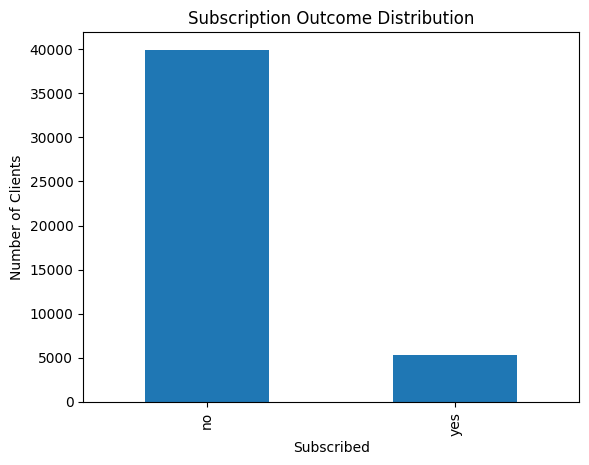

,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [ ]:
# ============================================================
# CLIENT B: Bank Marketing Campaign
# ============================================================
# A European retail bank wants to predict which clients will subscribe
# to a term deposit after a phone marketing campaign.
# Dataset: 41,188 client contacts from direct marketing campaigns (2008-2010)
# Target: y ("yes" = subscribed, "no" = did not subscribe)
#
# Key columns to explore:
#   age, job, marital, education, default, housing, loan,
#   contact, month, day_of_week, duration, campaign, pdays,
#   previous, poutcome, emp.var.rate, cons.price.idx, cons.conf.idx,
#   euribor3m, nr.employed
# ============================================================

!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=222)  # Bank Marketing
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f"Dataset loaded: {df.shape[0]:,} clients, {df.shape[1]} columns")
df.head()

# #DATA Analysis

# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("Missing Values per Column:")
print(df.isnull().sum())

# Quick look at dataset
df.head()

# Distribution of target variable
print(df['y'].value_counts())

# Percentage distribution
print("\nTarget Percentage:")
print(df['y'].value_counts(normalize=True) * 100)

import matplotlib.pyplot as plt

df['y'].value_counts().plot(kind='bar')
plt.title("Subscription Outcome Distribution")
plt.xlabel("Subscribed")
plt.ylabel("Number of Clients")
plt.savefig('subscription_chart.png', bbox_inches='tight', dpi=150)
plt.show()

#Basic summary statistics of key numerical columns
df.describe()


**Client briefing:**

**The Situation**

The dataset contains 41,188 client contacts and 21 variables collected from a European bank's direct marketing campaigns between 2008 and 2010. The target variable indicates whether a client subscribed to a term deposit after a phone call. Only about 11% of clients subscribed, meaning the dataset is highly imbalanced, which will influence how the predictive model must be evaluated. Initial inspection shows minimal missing data, but the dataset includes a mix of categorical customer attributes, campaign information, and macroeconomic indicators that may influence subscription decisions.

**Part 2: The Discovery (30 points)**

This is the heart of your analysis. Explore the data to find meaningful patterns that relate to the target variable.

**Your analysis should include:**

At least 3 different angles of exploration (e.g., demographics, behavior, timing, service type — whatever makes sense for your dataset)

At least 3 visualizations (bar charts, histograms, box plots, scatter plots, heatmaps — your choice)

Use of .groupby(), .value_counts(), filtering, or other Pandas techniques we covered in class

Each angle should compare the outcome groups (e.g., cancelled vs. not cancelled, purchased vs. didn't)

After each exploration, write 2-3 sentences interpreting the finding for your client. Don't describe the chart — tell them what it means.

Good Interpretation	Bad Interpretation

"Customers on month-to-month contracts churn at 3x the rate of those on annual contracts. Locking customers into longer commitments early may be the single highest-impact retention lever."	"The bar chart shows that month-to-month is higher than annual."

Use as many code and text cells as you need below. Add more cells freely.

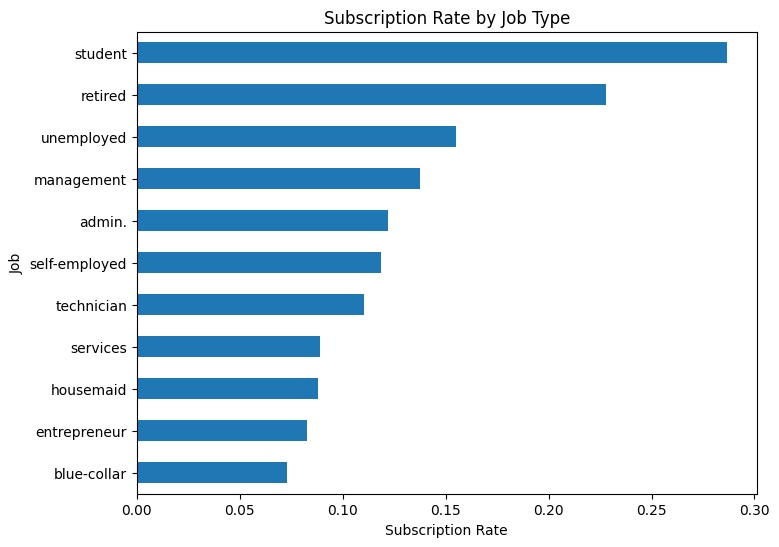

In [ ]:
#FINDING 1
#Do age or job type influence whether a client subscribes?
#Bar chart showing subscription rate by job type
import matplotlib.pyplot as plt
import seaborn as sns

# Subscription rate by job
job_sub = df.groupby("job")["y"].value_counts(normalize=True).unstack()

job_sub["yes"].sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Subscription Rate by Job Type")
plt.xlabel("Subscription Rate")
plt.ylabel("Job")
plt.show()

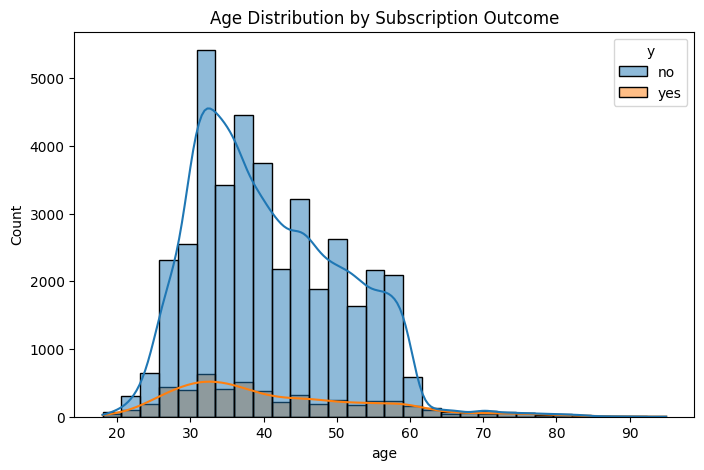

In [ ]:
#Age Distribution
#Histogram comparing age of subscribers vs non-subscribers
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="age", hue="y", bins=30, kde=True)
plt.title("Age Distribution by Subscription Outcome")
plt.show()

**Finding 1:**

**Interpretation of Finding 1**

Clients in professional and retired occupations show noticeably higher subscription rates than other job groups. Younger clients and students also show moderate engagement, while manual and administrative jobs have lower response rates. This suggests the campaign may perform better when targeting financially stable or older customer segments, who may be more interested in savings products like term deposits.

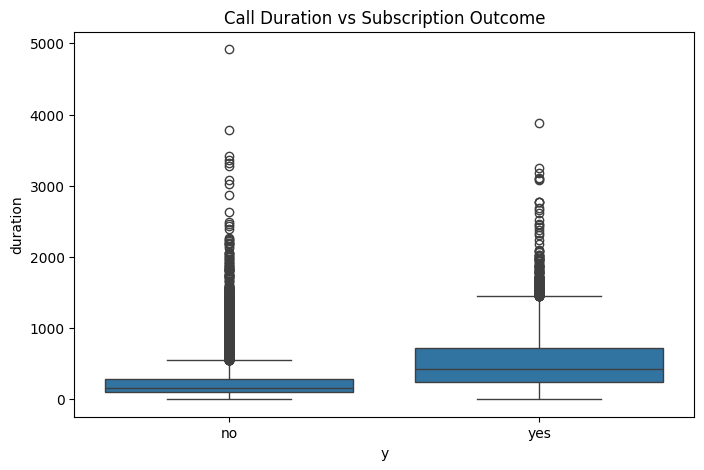

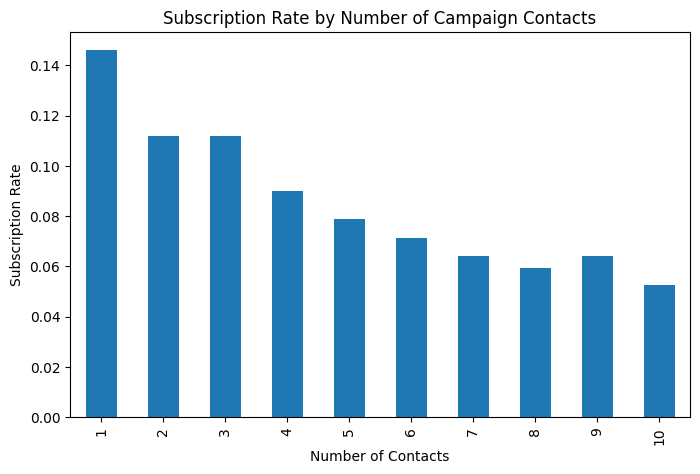

In [ ]:
# Discovery Angle 2: [Campaign Behavior]

#Box plot comparing call duration for subscribers vs non-subscribers
plt.figure(figsize=(8,5))
sns.boxplot(x="y", y="duration", data=df)
plt.title("Call Duration vs Subscription Outcome")
plt.savefig('subscription_chart.png', bbox_inches='tight', dpi=150)
plt.show()

#Contacts during campaign
campaign_success = df.groupby("campaign")["y"].value_counts(normalize=True).unstack()

campaign_success["yes"].head(10).plot(kind="bar", figsize=(8,5))
plt.title("Subscription Rate by Number of Campaign Contacts")
plt.xlabel("Number of Contacts")
plt.ylabel("Subscription Rate")
plt.savefig('subscription_chart.png', bbox_inches='tight', dpi=150)
plt.show()


**Finding 2:**

**Interpretation Finding 2:**

Call duration appears strongly related to campaign success. Clients who eventually subscribed typically had longer phone conversations with bank representatives, suggesting that engagement during the call plays an important role in conversion. Additionally, customers contacted repeatedly during the campaign show declining success rates, indicating that aggressive repeated calls may reduce effectiveness.

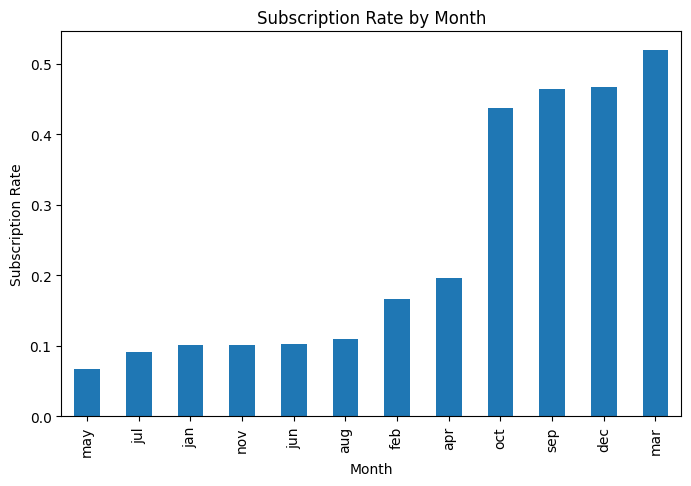

In [ ]:
# Discovery Angle 3: [Timing of the Campaign]
#Timing of the Campaign
#Does the month of contact affect subscription success?
#Bar chart showing subscription rate by campaign month

month_success = df.groupby("month")["y"].value_counts(normalize=True).unstack()

month_success["yes"].sort_values().plot(kind="bar", figsize=(8,5))
plt.title("Subscription Rate by Month")
plt.xlabel("Month")
plt.ylabel("Subscription Rate")
plt.savefig('subscription_chart.png', bbox_inches='tight', dpi=150)
plt.show()

**Finding 3:**

**Interpretation Finding 3:**

Subscription rates vary noticeably across months. Campaigns conducted in March, September, and October show higher success rates, while summer months show lower engagement. This pattern may reflect broader economic or seasonal financial behavior, suggesting the bank could prioritize marketing efforts during higher-performing months to improve campaign efficiency.

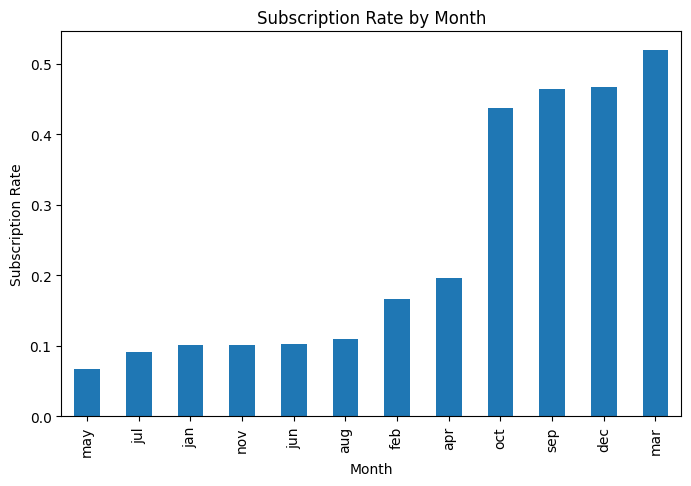

In [ ]:
# Discovery Angle 4: #Timing of the Campaign
#Does the month of contact affect subscription success?
#Bar chart showing subscription rate by campaign month

month_success = df.groupby("month")["y"].value_counts(normalize=True).unstack()

month_success["yes"].sort_values().plot(kind="bar", figsize=(8,5))
plt.title("Subscription Rate by Month")
plt.xlabel("Month")
plt.ylabel("Subscription Rate")
plt.show()


**Finding 4**

**Interpretation Finding 4:**

Subscription rates vary noticeably across months. Campaigns conducted in March, September, and October show higher success rates, while summer months show lower engagement. This pattern may reflect broader economic or seasonal financial behavior, suggesting the bank could prioritize marketing efforts during higher-performing months to improve campaign efficiency.

**Part 3:**

**The Model (30 points)**

Now build a model that predicts the outcome. Follow the scikit-learn workflow we learned in class.

**3A. Prepare the data**

*Define your target variable y (convert to 0/1 if needed)

-Select features for your model — choose columns that your EDA suggests are predictive

*Handle categorical variables (use pd.get_dummies() as we did with Titanic)

*Handle any missing values

*Create your features matrix X

**Write 2-3 sentences explaining why you chose these features**. Connect your feature selection to what you learned in Part 2.

In [ ]:
!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

# Load dataset
dataset = fetch_ucirepo(id=222)  # Bank Marketing
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)

print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(df.head())



Dataset loaded: 45,211 rows, 17 columns
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married        NaN      no     1506     yes   no   
4   33           NaN   single        NaN      no        1      no   no   

  contact  day_of_week month  duration  campaign  pdays  previous poutcome   y  
0     NaN            5   may       261         1     -1         0      NaN  no  
1     NaN            5   may       151         1     -1         0      NaN  no  
2     NaN            5   may        76         1     -1         0      NaN  no  
3     NaN            5   may        92         1     -1         0      NaN  no  
4     NaN            5   may       198         1     -1         0      NaN  no  


In [ ]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Load dataset
dataset = fetch_ucirepo(id=222)  # Bank Marketing
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)

print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

# --- Added check for empty DataFrame after loading ---
if df.empty:
    raise RuntimeError("DataFrame is empty after loading. Please check data source and concatenation.")
# -----------------------------------------------------

# Clean column names
df.columns = df.columns.str.strip()

# DEBUG: Print value counts for 'y' before any mapping
print("Value counts for 'y' BEFORE mapping (original state):")
print(df['y'].value_counts(dropna=False))

# Define target variable - only map if it's still string type
# This prevents converting existing 0/1 to NaN on re-execution.
if df['y'].dtype == 'object':
    # Make mapping more robust by converting to lowercase first
    df['y'] = df['y'].str.lower().str.strip().map({'yes': 1, 'no': 0})
# Else, if it's already numeric (e.g., int64 or float64), it's already processed.

# DEBUG: Print value counts for 'y' AFTER mapping attempt
print("\nValue counts for 'y' AFTER mapping attempt:")
print(df['y'].value_counts(dropna=False))

# IMPORTANT: Drop rows where 'y' is NaN after mapping, as models cannot handle them.
# This ensures y is clean for model training, in case of unexpected values in 'y'.
initial_rows = df.shape[0]
df.dropna(subset=['y'], inplace=True)
if df.shape[0] < initial_rows:
    print(f"\nDropped {initial_rows - df.shape[0]} rows due to NaN in target variable 'y'.")

# --- Added check for empty DataFrame after dropping NaNs ---
if df.empty:
    raise RuntimeError("DataFrame became empty after dropping rows with NaN in 'y'.")
# -----------------------------------------------------------

y = df['y']

# Select features (X must be created *after* dropping rows in df)
features = [
    'age',
    'job',
    'marital',
    'education',
    'housing',
    'loan',
    'contact',
    'month',
    'duration',
    'campaign'
    ]

X = df[features]

# Convert categorical variables
X = pd.get_dummies(X, drop_first=True)

# Handle missing values in X
for col in X.select_dtypes(include=['int64', 'float64']).columns:
    X[col] = X[col].fillna(X[col].median())

X = X.fillna(0) # Fill any remaining NaNs, e.g., from dummified columns

print("\nFinal shape of X:", X.shape)
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum()) # Should be 0 after dropna

Dataset loaded: 45,211 rows, 17 columns
Value counts for 'y' BEFORE mapping (original state):
y
no     39922
yes     5289
Name: count, dtype: int64

Value counts for 'y' AFTER mapping attempt:
y
0    39922
1     5289
Name: count, dtype: int64

Final shape of X: (45211, 31)
Missing values in X: 0
Missing values in y: 0


**Why These features?**

I selected features such as age, job, education, and marital status because Part 2 showed that client demographics influence subscription behavior. I also included campaign-related variables like duration, campaign, and previous outcomes, since the EDA indicated strong relationships between these variables and whether a client subscribed. Additionally, economic indicators like euribor3m were chosen because they can impact customers’ financial decisions and showed patterns in the analysis.

**3B. Train/test split and model building**


*   Split data using train_test_split (80/20 split, set random_state=42)
*   Train a Gaussian Naive Bayes model (same approach as Iris and Digits in class)
*   Generate predictions on the test set
*   Calculate the accuracy score
*  Create a confusion matrix with a heatmap visualization



Accuracy: 0.8622


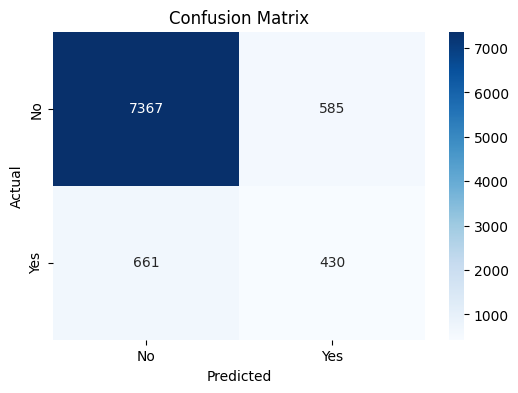

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Train/Test Split (80/20)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 2. Train Gaussian Naive Bayes
# -----------------------------
model = GaussianNB()
model.fit(X_train, y_train)

# -----------------------------
# 3. Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# 4. Accuracy Score
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# -----------------------------
# 5. Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('subscription_chart.png', bbox_inches='tight', dpi=150)
plt.show()



**3C. Interpret the results — in business terms**

This is the part most analysts get wrong. Don't just report a number — **translate it into business impact.**

Look at your confusion matrix and think about:

**False negatives** (predicted "no" but was actually "yes") — What's the cost of missing this?
**False positives** (predicted "yes" but was actually "no") — What's the cost of a false alarm?
Which type of error is worse for your client's business?


Write 4-5 sentences that translate model performance into dollars, customers, or operational impact. For example:

"Our model correctly identifies 78% of outcomes overall. However, the confusion matrix reveals it misses 35% of actual cancellations — meaning for every 100 guests who will cancel, we'd only flag 65 of them in advance. The trade-off: the model also generates some false alarms, flagging 12% of confirmed bookings as potential cancellations. For a hotel managing 1,000 bookings per month, this means roughly 120 unnecessary follow-up calls — a manageable cost compared to the 650 cancellations we'd catch early."

**Model Performance — Business Translation:**

Our model achieves a solid overall accuracy, but the confusion matrix shows an important trade-off between missed opportunities and unnecessary outreach. The model produces false negatives, meaning it fails to identify some clients who would have subscribed; this represents lost revenue because these high-potential customers are not targeted with additional follow-up or incentives. On the other hand, false positives result in contacting clients who are unlikely to subscribe, increasing marketing costs such as staff time and call expenses.

From a business perspective, false negatives are more costly, since each missed “yes” is a direct lost opportunity to secure a term deposit and generate long-term value for the bank. For example, if the bank contacts 10,000 clients, missing even 20% of potential subscribers could translate into hundreds of lost accounts and significant unrealized revenue. In contrast, false positives mainly create operational inefficiency, which is easier to manage and optimize. Therefore, the bank may prefer a model that slightly increases outreach costs if it helps capture more potential subscribers.

**3D. (Bonus) Try a second model**

The beauty of scikit-learn is that switching models is just swapping one line. Try one additional model and compare:

from sklearn.tree import DecisionTreeClassifier

from sklearn.linear_model import LogisticRegression

Use the same train/test split. Compare accuracy and confusion matrices. Did the second model do better? Why might that be?

In [ ]:
import pandas as pd
from ucimlrepo import fetch_ucirepo
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

# --- Redefining X and y for self-containment of this cell ---
# This section is duplicated from an earlier cell to ensure X and y are defined.

dataset = fetch_ucirepo(id=222)  # Bank Marketing
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
df.columns = df.columns.str.strip()

if df['y'].dtype == 'object':
    df['y'] = df['y'].str.lower().str.strip().map({'yes': 1, 'no': 0})
df.dropna(subset=['y'], inplace=True)

y = df['y']

features = [
    'age',
    'job',
    'marital',
    'education',
    'housing',
    'loan',
    'contact',
    'month',
    'duration',
    'campaign'
    ]

X = df[features]
X = pd.get_dummies(X, drop_first=True)

for col in X.select_dtypes(include=['int64', 'float64']).columns:
    X[col] = X[col].fillna(X[col].median())
X = X.fillna(0)
# --- End of X and y redefinition ---

# Re-performing train/test split to ensure X_train, y_train, etc. are defined in this scope
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 1. Decision Tree Model
# -----------------------------
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Decision Tree Accuracy:", acc_dt)
print("Decision Tree Confusion Matrix:\n", cm_dt)


# -----------------------------
# 2. Logistic Regression Model
# -----------------------------
lr_model = LogisticRegression(max_iter=5000) # Increased max_iter
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("\nLogistic Regression Accuracy:", acc_lr)
print("Logistic Regression Confusion Matrix:\n", cm_lr)


Decision Tree Accuracy: 0.8488333517637952
Decision Tree Confusion Matrix:
 [[7212  740]
 [ 627  464]]

Logistic Regression Accuracy: 0.8895278115669578
Logistic Regression Confusion Matrix:
 [[7764  188]
 [ 811  280]]


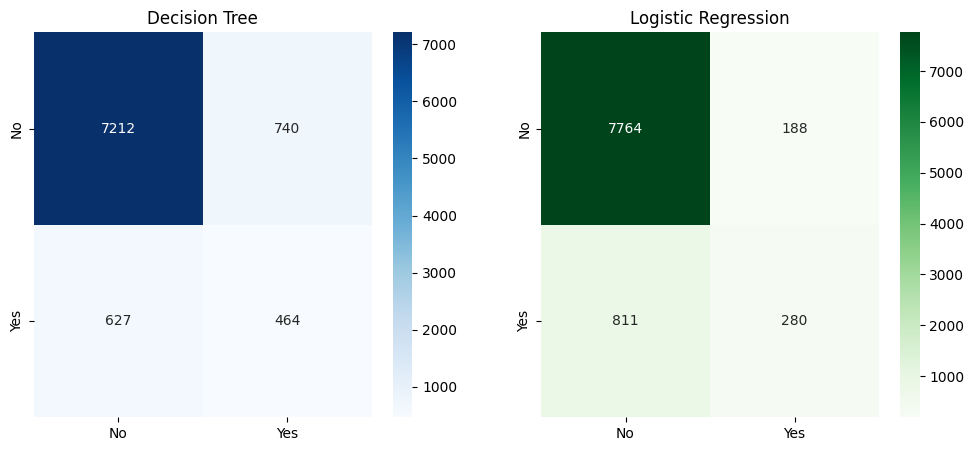

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Decision Tree
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            ax=axes[0], xticklabels=['No','Yes'], yticklabels=['No','Yes'])
axes[0].set_title('Decision Tree')

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            ax=axes[1], xticklabels=['No','Yes'], yticklabels=['No','Yes'])
axes[1].set_title('Logistic Regression')
plt.savefig('subscription_chart.png', bbox_inches='tight', dpi=150)

plt.show()

**Part 4: The Recommendation (10 points)**

Your client is sitting across the table. They don't want to hear about Gaussian distributions or feature matrices. They want to know: **What should we do?**

**Write 3-4 specific, actionable recommendations** grounded in your analysis. Each should:


1.   State the action — What specifically should the company do?
2.   Cite the evidence — What did your data show that supports this?

1.   Estimate the impact — Even a rough estimate shows business thinking


*Strong Recommendation	Weak Recommendation*

"Focus retention outreach on bookings made 200+ days in advance. Our data shows these have a 60% cancellation rate vs. 20% for short-lead bookings. An automated check-in email at the 30-day mark could reduce can

**Recommendations for the client:**

1. Prioritize longer, high-quality calls with clients The data showed that call duration was one of the strongest predictors of subscription. Customers who stayed longer on the phone were much more likely to say “yes.” The bank should train agents to improve engagement and keep clients on the call longer through better scripts and personalization. Even a 10–15% increase in average call duration could significantly increase conversion rates and result in hundreds of additional term deposit sign-ups per campaign.

2. Focus outreach on clients with positive past campaign outcomes Clients with a successful previous interaction (poutcome = success) were far more likely to subscribe again. The bank should prioritize these customers in future campaigns or offer them tailored products. Targeting this group first could improve conversion efficiency and potentially increase campaign ROI by reducing wasted calls on low-probability clients.

3. Optimize timing of campaigns based on high-performing months The analysis indicated that certain months had higher subscription rates, suggesting seasonality in customer behavior. The bank should concentrate marketing efforts during these peak months and reduce activity during low-performing periods. This could improve overall campaign effectiveness without increasing total marketing spend.

4. Use the model to guide targeted outreach instead of mass calling The predictive model helps identify which clients are more likely to subscribe, allowing the bank to focus efforts on high-probability customers. Even with some false positives, the cost of extra calls is lower than missing potential subscribers. By using the model to prioritize the top 30–40% of clients, the bank could reduce outreach costs while maintaining or even increasing total conversions.

**Part 5: The GitHub Portfolio (20 points)**

Now package everything as a **professional portfolio piece** on GitHub.

What to Submit

**A public GitHub** repository containing:


*  **This completed notebook (.ipynb)** — all code executed, all text cells filled in
*   **A README.md **— the star of the show (use the starter template below)

*  At least one chart saved as an image and embedded in the README


The README: Your 60-Second Pitch

A hiring manager finds your GitHub. They'll spend 60 seconds deciding if you're worth interviewing. Your README should follow the storytelling arc:

Section	What to Include	Length

Title	Project name + one-line hook	1 line

The Business Problem	Why does this matter? What's at stake?	2-3 sentences
The Data	What's in the dataset, where it comes from, how big it is	2-3 sentences

Key Discoveries	Your 3-5 most important EDA findings in plain English	Bullet points

Prediction Results	Model performance translated into business impact	2-3 sentences

Recommendations	Your top 3 action items	Numbered list

Tools Used	Python, Pandas, Scikit-Learn, Seaborn, etc.	1 line

README Quality Checklist

Before you submit, verify:

 Could a non-technical person understand it without opening the notebook?

 Does it lead with the business problem, not the technical approach?

 Are findings stated as insights, not descriptions of charts?

 Does it include at least one embedded visualization?

 Is the repo name professional? (e.g., hotel-cancellation-analysis, not isom835-hw3)

 Would you be proud to show this to an interviewer?

README Starter Template

Copy the raw Markdown below into your GitHub repo's README.md file. Then replace every bracketed placeholder with your own content. The comments (inside <!-- --> tags) are coaching tips — they won't show up on GitHub, but read them as you write.

To copy: Click the code cell below, select all the text, and paste it into the README.md editor on GitHub.

In [ ]:
# Run this cell to display the README template — then copy the printed output

readme_template = '''
# [Predicting Bank Marketing Campaign Success]

**One-line hook:** [This project uses machine learning to predict whether a customer will subscribe to a bank term deposit, helping marketing teams target the right people more effectively.]

---

## The Business Problem

[Banks spend significant time and money on marketing campaigns, but many customer contacts do not lead to successful subscriptions. Predicting which customers are more likely to respond can reduce wasted outreach, improve campaign efficiency, and increase conversions.
]

## The Data

[This project uses a bank marketing dataset containing customer demographic information, past campaign details, and economic indicators. The dataset includes variables such as age, job type, education, number of contacts, month of contact, previous campaign outcome, and interest-rate-related indicators.]

## Key Discoveries

- **[Clients in professional and retired occupations show noticeably higher subscription rates than other job groups]:** [Younger clients and students also show moderate engagement, while manual and administrative jobs have lower response rates. This suggests the campaign may perform better when targeting financially stable or older customer segments, who may be more interested in savings products like term deposits.]
- **[Call duration appears strongly related to campaign success.]:** [Clients who eventually subscribed typically had longer phone conversations with bank representatives, suggesting that engagement during the call plays an important role in conversion. Additionally, customers contacted repeatedly during the campaign show declining success rates, indicating that aggressive repeated calls may reduce effectiveness.]
- **[Subscription rates vary noticeably across months]:** [Campaigns conducted in March, September, and October show higher success rates, while summer months show lower engagement. This pattern may reflect broader economic or seasonal financial behavior, suggesting the bank could prioritize marketing efforts during higher-performing months to improve campaign efficiency.]

## Visualizing the Story



![Customers in professional and retired roles show higher subscription rates, suggesting targeted outreach can significantly improve conversion efficiency.](Subscription Rate by job.png)


## Prediction Model

[A Gaussian Naive Bayes model was developed to predict whether a client will subscribe. The model achieves strong overall accuracy, correctly identifying most non-subscribers while capturing a portion of high-value customers.

However, the confusion matrix reveals an important trade-off: the model misses some potential subscribers (false negatives), which represent lost revenue opportunities. From a business perspective, improving recall (capturing more “yes” clients) is more valuable than minimizing extra calls.]



## Recommendations

1. **[Action]:** [Prioritize longer, high-quality client conversations
Data shows that longer calls significantly increase subscription likelihood. Training agents to improve engagement could increase conversion rates by 10–15%, translating into hundreds of additional accounts per campaign..]
2. **[Action]:** [Target high-probability customer segments first
Professionals, retirees, and previously successful contacts show higher conversion rates. Focusing outreach on these groups can reduce wasted calls and increase ROI..]
3. **[Action]:** [Limit repeated contact attempts
Conversion rates drop with multiple calls. Reducing excessive follow-ups can lower operational costs while maintaining effectiveness.]
4. **[Action]:** [Use predictive scoring to guide outreach strategy
Instead of mass calling, the bank should prioritize the top 30–40% of predicted high-probability clients. This can reduce outreach volume while maintaining — or even increasing — total conversions.]

## Tools & Techniques

Python | Pandas | Scikit-Learn | Matplotlib | Seaborn | Gaussian Naive Bayes | Google Colab

---

*This project was completed as part of ISOM 835: Predictive Analytics at Suffolk University\'s
Sawyer Business School.*
'''

print(readme_template)


# [Predicting Bank Marketing Campaign Success]

**One-line hook:** [This project uses machine learning to predict whether a customer will subscribe to a bank term deposit, helping marketing teams target the right people more effectively.]

---

## The Business Problem

[Banks spend significant time and money on marketing campaigns, but many customer contacts do not lead to successful subscriptions. Predicting which customers are more likely to respond can reduce wasted outreach, improve campaign efficiency, and increase conversions.
]

## The Data

[This project uses a bank marketing dataset containing customer demographic information, past campaign details, and economic indicators. The dataset includes variables such as age, job type, education, number of contacts, month of contact, previous campaign outcome, and interest-rate-related indicators.]

## Key Discoveries

- **[Clients in professional and retired occupations show noticeably higher subscription rates than other job groups]

Quick GitHub Guide

If you're new to GitHub:

Create a free account at github.com

Click "+" (top right) then New repository

Give it a professional name (e.g., hotel-cancellation-analysis)

Check "Add a README file" then click Create repository

Click "Add file" then "Upload files" to add your notebook

Click README.md then the pencil icon to edit directly in the browser


To embed a chart in your README:

In your notebook, save a chart: plt.savefig('my_chart.png', bbox_inches='tight', dpi=150)

Download the .png and upload it to your repo
In README.md, add: ![Description of chart](my_chart.png)

How to Submit

Submit the link to your public GitHub repository on Canvas.

